<p style="font-family: 'Georgia', serif; font-size: 60px; text-align: center; color: #1F77B4;">Health Care Data Analysis</p>

***👨‍💻Author: OLUWANIFEMI ADEOTI***

 [![GitHub](https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github)](https://github.com/OluwanifemiAdeoti?tab=repositories)

  [![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin)](http://www.linkedin.com/in/oluwanifemiadeoti)

   [![Kaggle](https://img.shields.io/badge/Kaggle-Profile-blue?style=for-the-badge&logo=kaggle)](https://www.kaggle.com/oluwanifemiadeoti)

  [![Gmail](https://img.shields.io/badge/Gmail-Contact%20Me-red?style=for-the-badge&logo=gmail)](mailto:oluwanifemiadeoti2@gmail.com)

**Data Information: Healthcare Dataset**
---



This dataset contains information about patients diagnosed with either of 6 chronic medical conditions admitted to a hospital, including demographic details, medical conditions, treatments, test results, and billing information. The dataset comprises the following columns:

- **Name**: Names of the patient associated with the healthcare record.
- **Age**: Age of the patients at the time of admission expressed in years.
- **Gender**: Gender of the patients either Male or Female.
- **Blood Type**: Blood type of the patients.
- **Medical Condition**: Description of the medical condition or diagnosis for which the patient is admitted.
- **Date of Admission**: Date when the patient was admitted to the hospital.
- **Doctor**: Name or identifier of the doctor responsible for the patient's care.
- **Hospital**: Name or identifier of the hospital where the patient is admitted.
- **Insurance Provider**: Name of the insurance provider covering the patient's medical expenses.
- **Billing Amount**: The amount of money billed for the patient's healthcare services during their admission.
- **Room Number**: The room number where the patient was accommodated during their admission.
- **Admission Type**: Type of admission, such as emergency, elective, or transfer.
- **Discharge Date**: Date when the patient was discharged from the hospital.
- **Medication**: List of medications prescribed to the patient during their hospitalization.
- **Test Results**: Results of medical tests conducted on the patient during the patient's admission.

This dataset provides valuable insights into patient demographics, medical conditions, treatment patterns, and hospital operations. It can be used for various analyses, including patient outcome prediction, resource allocation optimization, and healthcare quality improvement initiatives.

---

📌 **Data Assumptions & Limitations**
---

This analysis was conducted on a dataset that does not include a unique patient identifier (e.g., patient ID). As a result, the name column was used as a proxy to represent individual patients.

It is important to note that:

- Names are not guaranteed to be unique, and multiple individuals may share the same name.
- Some patient attributes (e.g., age group, gender) may appear inconsistent across records for the same name.

Due to this limitation:

- Patient-level analyses (e.g., number of unique patients, repeat visits, condition distribution by patient) should be interpreted as estimates.
- Admission-level analyses (e.g., total visits, condition frequency, temporal trends) are fully accurate, as they rely on individual records rather than inferred identities.

This notebook is intended for learning purposes, demonstrating data cleaning, transformation, and exploratory analysis, as well as highlighting real-world data challenges such as missing unique identifiers.

<p style="font-family:'Trebuchet MS', sans-serif; font-size: 40px; text-align: center; color: #2CA02C;">Importing the Libraries</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 

In [2]:
healthcare = pd.read_csv("C:\\Users\\Oluwanifemi\\OneDrive\\Documents\\Projects\\Healthcare Analysis\\healthcare_dataset.csv")

<p style="font-family:'Trebuchet MS', sans-serif; font-size: 20px; text-align: left; color: #1F77B4;">Preview of the Data & Data Cleaning</p>

In [3]:
healthcare.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
#Check for null values and wrong data types
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [5]:
# Convert dates to datetime format
healthcare['Date of Admission']= pd.to_datetime(healthcare['Date of Admission'])
healthcare['Discharge Date']= pd.to_datetime(healthcare['Discharge Date'])

In [6]:
healthcare.columns=healthcare.columns.str.lower().str.replace(' ','_')

In [7]:
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                55500 non-null  object        
 1   age                 55500 non-null  int64         
 2   gender              55500 non-null  object        
 3   blood_type          55500 non-null  object        
 4   medical_condition   55500 non-null  object        
 5   date_of_admission   55500 non-null  datetime64[ns]
 6   doctor              55500 non-null  object        
 7   hospital            55500 non-null  object        
 8   insurance_provider  55500 non-null  object        
 9   billing_amount      55500 non-null  float64       
 10  room_number         55500 non-null  int64         
 11  admission_type      55500 non-null  object        
 12  discharge_date      55500 non-null  datetime64[ns]
 13  medication          55500 non-null  object    

In [8]:
# Check for missing values, outliers, impossible values
healthcare.describe()

,age,date_of_admission,billing_amount,room_number,discharge_date
count,55500.000000,55500,55500.000000,55500.000000,55500
mean,51.539459,2021-11-01 01:02:22.443243008,25539.316097,301.134829,2021-11-16 13:15:20.821621504
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00
50%,52.000000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00
75%,68.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.602454,NaN,14211.454431,115.243069,NaN


In [9]:
# Investigate negatives in billing amount
healthcare[healthcare['billing_amount']< 0]

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
132,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
799,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
1421,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52894,JosEPh cOx,23,Male,AB-,Diabetes,2019-10-13,Peter Smith,Inc Ward,Blue Cross,-353.865186,271,Elective,2019-10-25,Lipitor,Inconclusive
53204,AsHley WaRnER,55,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
53232,dAnIel dRaKe,68,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal
54136,DR. micHaEl MckAy,64,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal


In [10]:
# Correct name data format
healthcare['name']=healthcare['name'].str.lower()

In [11]:
healthcare.describe(include='object').T

,count,unique,top,freq
name,55500,40235,michael williams,24
gender,55500,2,Male,27774
blood_type,55500,8,A-,6969
medical_condition,55500,6,Arthritis,9308
doctor,55500,40341,Michael Smith,27
hospital,55500,39876,LLC Smith,44
insurance_provider,55500,5,Cigna,11249
admission_type,55500,3,Elective,18655
medication,55500,5,Lipitor,11140
test_results,55500,3,Abnormal,18627


In [12]:
healthcare[healthcare['billing_amount']< 0].min()

name                        aaron flowers
age                                    18
gender                             Female
blood_type                             A+
medical_condition               Arthritis
date_of_admission     2019-05-20 00:00:00
doctor                         Adam Pitts
hospital                      Aguilar Inc
insurance_provider                  Aetna
billing_amount                -2008.49214
room_number                           115
admission_type                   Elective
discharge_date        2019-05-27 00:00:00
medication                        Aspirin
test_results                     Abnormal
dtype: object

In [13]:
# Check for duplicates
healthcare.duplicated().sum()

np.int64(534)

In [14]:
# Drop duplicates 
healthcare.drop_duplicates(inplace=True)

In [15]:
healthcare.duplicated().sum()

np.int64(0)

In [16]:
# Preview Data 
healthcare

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,bobby jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,leslie terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,danny smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrew watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrienne bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,elizabeth jackson,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,kyle perez,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,heather wang,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,jennifer jones,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [17]:
(healthcare['billing_amount']< 0).sum()

np.int64(106)

In [18]:
# Save negative billing amount in variable for data transparency and future analysis 
negative_billing = healthcare[healthcare['billing_amount']<0]

In [19]:
negative_billing.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
132,ashley erickson,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
799,christopher weiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,ashley warner,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
1421,jay galloway,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,joshua williamson,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal


In [20]:
# Remove negative billing amount from data
healthcare=healthcare[healthcare['billing_amount']>0]

In [21]:
healthcare=healthcare.copy()

In [22]:
healthcare.describe()

,age,date_of_admission,billing_amount,room_number,discharge_date
count,54860.000000,54860,54860.000000,54860.000000,54860
mean,51.533850,2021-11-01 19:01:50.506744576,25594.633637,301.109752,2021-11-17 07:00:08.137076224
min,13.000000,2019-05-08 00:00:00,9.238787,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13299.747940,202.000000,2020-08-13 00:00:00
50%,52.000000,2021-11-02 00:00:00,25593.873000,302.000000,2021-11-18 00:00:00
75%,68.000000,2023-02-03 00:00:00,37847.066671,400.000000,2023-02-19 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.605295,NaN,14175.867041,115.217195,NaN


In [23]:
healthcare.describe(include='object').T

,count,unique,top,freq
name,54860,40167,michael williams,24
gender,54860,2,Male,27449
blood_type,54860,8,A-,6882
medical_condition,54860,6,Arthritis,9207
doctor,54860,40276,Michael Smith,27
hospital,54860,39815,LLC Smith,44
insurance_provider,54860,5,Cigna,11115
admission_type,54860,3,Elective,18437
medication,54860,5,Lipitor,11018
test_results,54860,3,Abnormal,18399


In [24]:
# Ensure accuracy among unique values for all rows
healthcare['blood_type'].unique()

array(['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-'], dtype=object)

In [25]:
healthcare['medical_condition'].unique()

array(['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension',
       'Arthritis'], dtype=object)

In [26]:
healthcare['insurance_provider'].unique()

array(['Blue Cross', 'Medicare', 'Aetna', 'UnitedHealthcare', 'Cigna'],
      dtype=object)

In [27]:
healthcare['admission_type'].unique()

array(['Urgent', 'Emergency', 'Elective'], dtype=object)

In [28]:
healthcare['medication'].unique()

array(['Paracetamol', 'Ibuprofen', 'Aspirin', 'Penicillin', 'Lipitor'],
      dtype=object)

In [29]:
healthcare['test_results'].unique()

array(['Normal', 'Inconclusive', 'Abnormal'], dtype=object)

In [30]:
# Quick check
healthcare[healthcare['date_of_admission']> healthcare['discharge_date']]

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results


In [31]:
# Feature engineering - derive new columns
healthcare.loc[:, 'length_of_stay']=(healthcare['discharge_date']-healthcare['date_of_admission']).dt.days

In [32]:
healthcare['length_of_stay'].dtype

dtype('int64')

In [33]:
healthcare['day']=healthcare['date_of_admission'].dt.day_name()

In [34]:
def age_group(age):
    if age >= 13 and age <= 19:
        return "Teen"
    elif age >= 20 and age <= 29:
        return "Young adult"
    elif age >= 30 and age <= 59:
        return "Adult"
    else:
        return "Elderly"

In [35]:
healthcare.loc[:,'age_group']= healthcare['age'].apply(age_group)

In [36]:
healthcare=healthcare[['name','gender','age','age_group','blood_type','medical_condition','date_of_admission','day','doctor','hospital','insurance_provider','billing_amount','room_number','admission_type','discharge_date','length_of_stay','medication','test_results']]

In [37]:
# FINAL CHECKS
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54860 entries, 0 to 55499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                54860 non-null  object        
 1   gender              54860 non-null  object        
 2   age                 54860 non-null  int64         
 3   age_group           54860 non-null  object        
 4   blood_type          54860 non-null  object        
 5   medical_condition   54860 non-null  object        
 6   date_of_admission   54860 non-null  datetime64[ns]
 7   day                 54860 non-null  object        
 8   doctor              54860 non-null  object        
 9   hospital            54860 non-null  object        
 10  insurance_provider  54860 non-null  object        
 11  billing_amount      54860 non-null  float64       
 12  room_number         54860 non-null  int64         
 13  admission_type      54860 non-null  object        


In [38]:
healthcare.describe(include='object').T

,count,unique,top,freq
name,54860,40167,michael williams,24
gender,54860,2,Male,27449
age_group,54860,4,Adult,24363
blood_type,54860,8,A-,6882
medical_condition,54860,6,Arthritis,9207
day,54860,7,Tuesday,7896
doctor,54860,40276,Michael Smith,27
hospital,54860,39815,LLC Smith,44
insurance_provider,54860,5,Cigna,11115
admission_type,54860,3,Elective,18437


In [39]:
healthcare.describe()

,age,date_of_admission,billing_amount,room_number,discharge_date,length_of_stay
count,54860.000000,54860,54860.000000,54860.000000,54860,54860.000000
mean,51.533850,2021-11-01 19:01:50.506744576,25594.633637,301.109752,2021-11-17 07:00:08.137076224,15.498815
min,13.000000,2019-05-08 00:00:00,9.238787,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13299.747940,202.000000,2020-08-13 00:00:00,8.000000
50%,52.000000,2021-11-02 00:00:00,25593.873000,302.000000,2021-11-18 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37847.066671,400.000000,2023-02-19 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00,30.000000
std,19.605295,NaN,14175.867041,115.217195,NaN,8.661357


OBSERVATIONS:

Temporal Coverage:
The data spans from 8th May 2019 to 7th May 2024, covering 54,860 patient admissions over five years. 

Patient insight:
During the period, Michael Williams was the most frequent patient, with 24 hospital visits.

Patient Age Range:
Patients range from 13 to 89 years old, with an average age of 52 years.

Gender Distribution:
Male patients accounted for the majority of visits, with 27,449 admissions.

Hospital Room Capacity:
Rooms range from 101 to 500, indicating flexible patient accommodation capacity.

Admission Types:
There are three admission types: Emergency, Elective, and Urgent, with Elective admissions being the highest (18,437 cases).

Blood Type Distribution:
Patients exhibit 8 blood types, with A- being the most prevalent (6,882 cases).

Hospital Distribution:
There are 39,876 unique hospitals, with LLC Smith being the most frequent (44 cases).

Doctor Distribution:
There are 40,341 unique doctors, with Michael Smith attending the most patients (27 cases).

Medical Conditions:
Patients present 6 medical conditions, with Arthritis being the most common (9,207 cases).

Medications Used:
Five medications were recorded, with Lipitor being the most frequently prescribed (11,018 cases).

Day of Admission:
Tuesday recorded the highest number of admissions.

Test Results:
Most test results were Abnormal (18,399 cases) compared to Normal and Inconclusive results.

Insurance Providers:
There are 5 insurance providers, with Cigna Insurance leading (11,115 cases).

Length of Stay:
The average hospital stay is 15 days, ranging from 1 to 30 days.

In [40]:
#Categorical columns
healthcare.columns

Index(['name', 'gender', 'age', 'age_group', 'blood_type', 'medical_condition',
       'date_of_admission', 'day', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'length_of_stay', 'medication', 'test_results'],
      dtype='object')

<p style="font-family:'Trebuchet MS', sans-serif; font-size: 20px; text-align: left; color: #1F77B4;">Value counts by Total admission</p>

In [41]:
print(healthcare['gender'].value_counts()) 

gender
Male      27449
Female    27411
Name: count, dtype: int64


In [42]:
print(healthcare['age_group'].value_counts()) 

age_group
Adult          24363
Elderly        20908
Young adult     7915
Teen            1674
Name: count, dtype: int64


In [43]:
print(healthcare['blood_type'].value_counts()) 

blood_type
A-     6882
A+     6879
B+     6876
AB+    6872
B-     6861
AB-    6859
O+     6843
O-     6788
Name: count, dtype: int64


In [44]:
print(healthcare['medical_condition'].value_counts()) 

medical_condition
Arthritis       9207
Diabetes        9197
Hypertension    9131
Obesity         9127
Cancer          9121
Asthma          9077
Name: count, dtype: int64


In [45]:
print(healthcare['day'].value_counts()) 

day
Tuesday      7896
Thursday     7893
Wednesday    7859
Sunday       7839
Saturday     7809
Friday       7802
Monday       7762
Name: count, dtype: int64


In [46]:
print(healthcare['insurance_provider'].value_counts()) 

insurance_provider
Cigna               11115
Medicare            11018
UnitedHealthcare    10995
Blue Cross          10937
Aetna               10795
Name: count, dtype: int64


In [47]:
print(healthcare['admission_type'].value_counts()) 

admission_type
Elective     18437
Urgent       18353
Emergency    18070
Name: count, dtype: int64


In [48]:
print(healthcare['medication'].value_counts()) 

medication
Lipitor        11018
Ibuprofen      11002
Aspirin        10963
Paracetamol    10945
Penicillin     10932
Name: count, dtype: int64


In [49]:
print(healthcare['test_results'].value_counts()) 

test_results
Abnormal        18399
Normal          18302
Inconclusive    18159
Name: count, dtype: int64


In [50]:
print(healthcare['test_results'].value_counts()) 

test_results
Abnormal        18399
Normal          18302
Inconclusive    18159
Name: count, dtype: int64


<p style="font-family:'Trebuchet MS', sans-serif; font-size: 60px; text-align: center; color: #1F77B4;">Data Visualization</p>

<p style="font-family:'Trebuchet MS', sans-serif; font-size: 20px; text-align: left; color: #1F77B4;">OVERVIEW - EXECUTIVE SUMMARY</p>

In [51]:
total_patients= healthcare['name'].nunique()
print(f"A total of {total_patients} patients were admitted.")

A total of 40167 patients were admitted.


In [52]:
total_revenue = healthcare['billing_amount'].sum()
print(f"A total revenue of ${round(total_revenue)} was generated over the five-year period.")

A total revenue of $1404121601 was generated over the five-year period.


In [53]:
avg_length_stay= healthcare['length_of_stay'].mean()
print(f"The average length of hospital stay is {round(avg_length_stay)} days.")

The average length of hospital stay is 15 days.


In [54]:
total_admissions= healthcare['date_of_admission'].count()
print(f"A total of {total_admissions} admissions were recorded over the five-year period.")

A total of 54860 admissions were recorded over the five-year period.


In [55]:
age_counts = (healthcare.groupby('age_group')['name'].nunique().reset_index(name='unique_patients'))
fig = px.bar(
    age_counts,
    x='age_group',
    y='unique_patients',
    color='age_group',
    title='Distribution of Patients by Age Group'
)

fig.show()

In [56]:
order = ['Male', 'Female']

gender_counts = (healthcare.groupby('gender')['name'].nunique().reindex(order).reset_index(name='unique_patients'))
fig = px.bar(
    gender_counts,
    x='gender',
    y='unique_patients',
    color='gender',
    category_orders={'gender': order},
    title='Distribution of  Patients by Gender'
)

fig.update_layout(
    xaxis_title='Gender',
    yaxis_title='Total Patients'
)

fig.show()

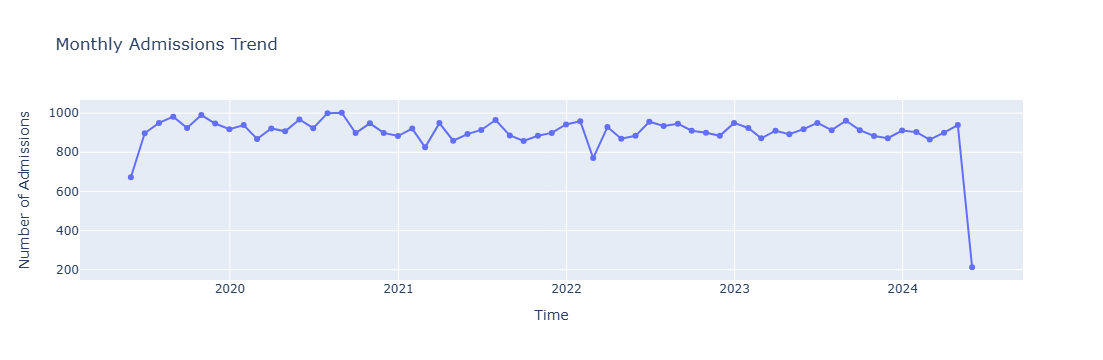

In [57]:
monthly_admissions = (healthcare.set_index('date_of_admission').resample('ME').size().reset_index(name='count'))

# Plot
fig = px.line(
    monthly_admissions,
    x='date_of_admission',
    y='count',
    title='Monthly Admissions Trend',
    markers=True  # equivalent to marker='o'
)

fig.update_layout(
    xaxis_title='Time',
    yaxis_title='Number of Admissions'
)

fig.show()

In [58]:
admission_counts = healthcare['admission_type'].value_counts().reset_index()
admission_counts.columns = ['admission_type', 'count']

fig = px.bar(
    admission_counts,
    x='admission_type',
    y='count',
    color='admission_type',
    title='Admission Distribution by Admission Type',
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.show()

In [59]:
# Extract year and day
healthcare['year'] = healthcare['date_of_admission'].dt.year

# Create peak dataframe
peak = (
    healthcare
    .groupby(['year', 'day'], observed=True)
    .size()
    .reset_index(name='count')
)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

peak['day'] = pd.Categorical(peak['day'], categories=day_order, ordered=True)
peak = peak.sort_values(['year', 'day'])

fig = px.bar(
    peak,
    x='year',
    y='count',
    color='day',
    category_orders={'day': day_order},
    barmode='group',
    title='Weekly Distribution by Year'
)

fig.show()

<p style="font-family:'Trebuchet MS', sans-serif; font-size: 20px; text-align: left; color: #1F77B4;">MEDICAL AND TREATMENT INSIGHTS</p>

In [60]:
condition_counts = (
    healthcare['medical_condition']
    .value_counts()
    .reset_index()
)

condition_counts.columns = ['medical_condition', 'visits']
fig = px.pie(
    condition_counts,
    names='medical_condition',
    values='visits',
    title='Distribution of Medical Conditions (by Visits)'
)

fig.show()

In [61]:
condition_gender = (healthcare.groupby(['medical_condition', 'gender'])['name'].nunique().reset_index(name='unique_patients'))
fig = px.bar(
    condition_gender,
    x='medical_condition',
    y='unique_patients',
    color='gender',
    barmode='group',
    title='Distribution of Medical Conditions by Gender (Unique Patients)'
)

fig.update_layout(
    xaxis_title='Medical Condition',
    yaxis_title='Number of Unique Patients'
)

fig.show()

In [62]:
condition_agegroup = (healthcare.groupby(['medical_condition', 'age_group'])['name'].nunique().reset_index(name='unique_patients'))
fig = px.bar(
    condition_agegroup,
    x='age_group',
    y='unique_patients',
    color='medical_condition',
    barmode='group',
    title='Distribution of Medical Conditions by Age group (Unique Patients)'
)

fig.update_layout(
    xaxis_title='Age Group',
    yaxis_title='Number of Unique Patients'
)

fig.show()

In [63]:
gender_admissiontype = (
    healthcare
    .groupby(['admission_type', 'gender'])
    .size()
    .reset_index(name='count')
)
gender_admissiontype['percentage'] = (
    gender_admissiontype
    .groupby('admission_type')['count']
    .transform(lambda x: x / x.sum() * 100)
)
fig = px.bar(
    gender_admissiontype,
    x='admission_type',
    y='percentage',
    color='gender',
    barmode='group',
    title='Gender Distribution by Admission Type (%)'
)

fig.show()

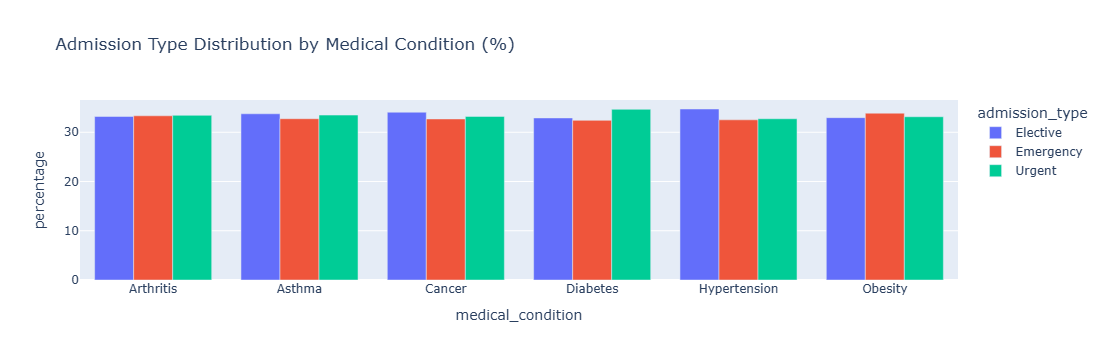

In [64]:
condition_admission_pct  = (healthcare.groupby(['medical_condition', 'admission_type']).size().reset_index(name='count'))

condition_admission_pct['percentage'] = (
    condition_admission_pct
    .groupby('medical_condition')['count']
    .transform(lambda x: x / x.sum() * 100)
)

fig = px.bar(
    condition_admission_pct,
    x='medical_condition',
    y='percentage',
    color='admission_type',
    barmode='group',
    title='Admission Type Distribution by Medical Condition (%)'
)

fig.show()


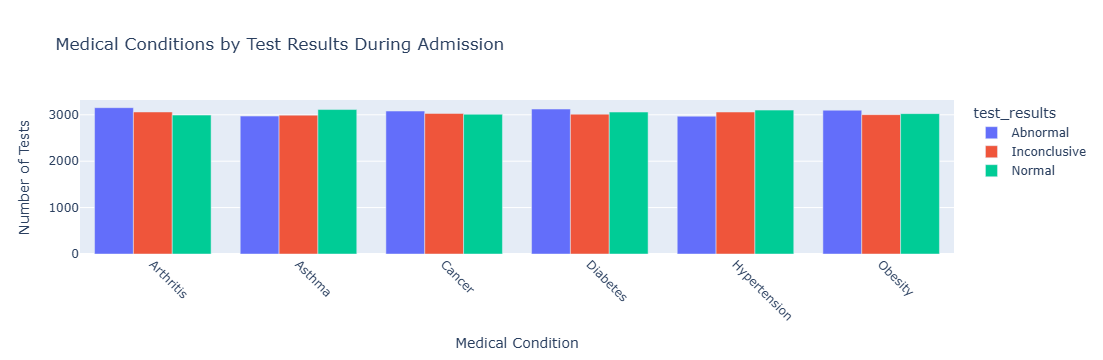

In [65]:
condition_test = (
    healthcare
    .groupby(['medical_condition', 'test_results'])
    .size()
    .reset_index(name='count')
)

fig = px.bar(
    condition_test,
    x='medical_condition',
    y='count',
    color='test_results',
    barmode='group',
    title='Medical Conditions by Test Results During Admission'
)

fig.update_layout(
    xaxis_title='Medical Condition',
    yaxis_title='Number of Tests'
)

fig.update_xaxes(tickangle=45)

fig.show()

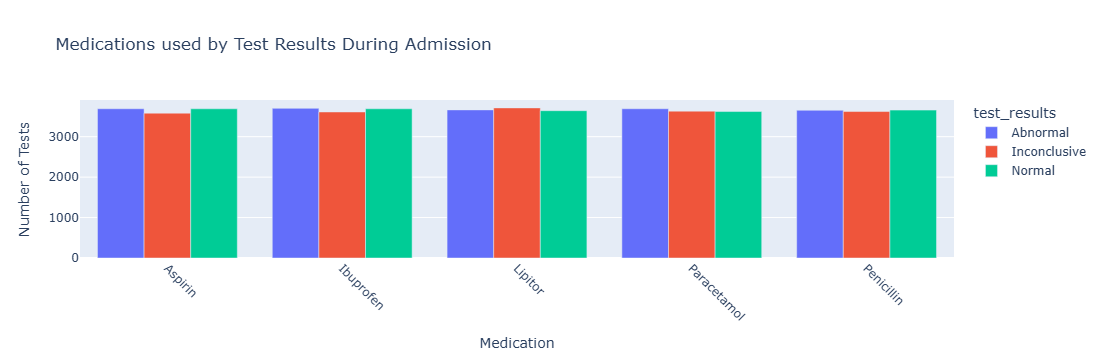

In [66]:
med_test = (healthcare.groupby(['medication', 'test_results']).size().reset_index(name='count'))
fig = px.bar(
    med_test,
    x='medication',
    y='count',
    color='test_results',
    barmode='group',
    title='Medications used by Test Results During Admission'
)

fig.update_layout(
    xaxis_title='Medication',
    yaxis_title='Number of Tests'
)

fig.update_xaxes(tickangle=45)

fig.show()

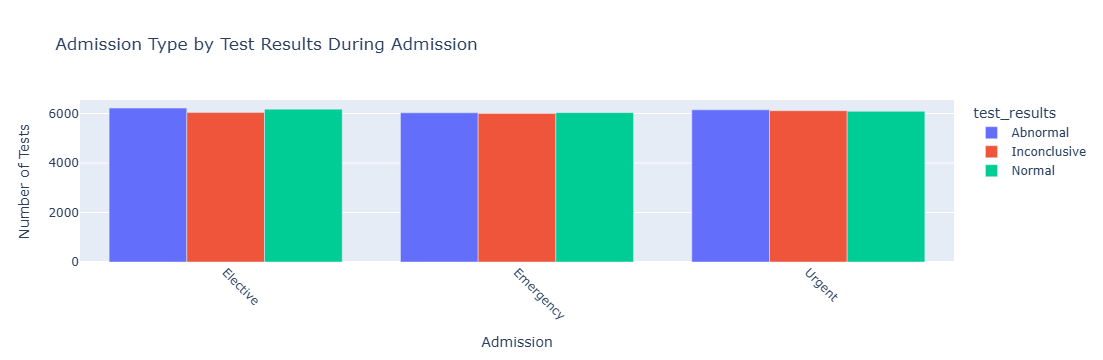

In [67]:
admission_test = (healthcare.groupby(['admission_type', 'test_results']).size().reset_index(name='count'))
fig = px.bar(
    admission_test,
    x='admission_type',
    y='count',
    color='test_results',
    barmode='group',
    title='Admission Type by Test Results During Admission'
)

fig.update_layout(
    xaxis_title='Admission',
    yaxis_title='Number of Tests'
)

fig.update_xaxes(tickangle=45)

fig.show()

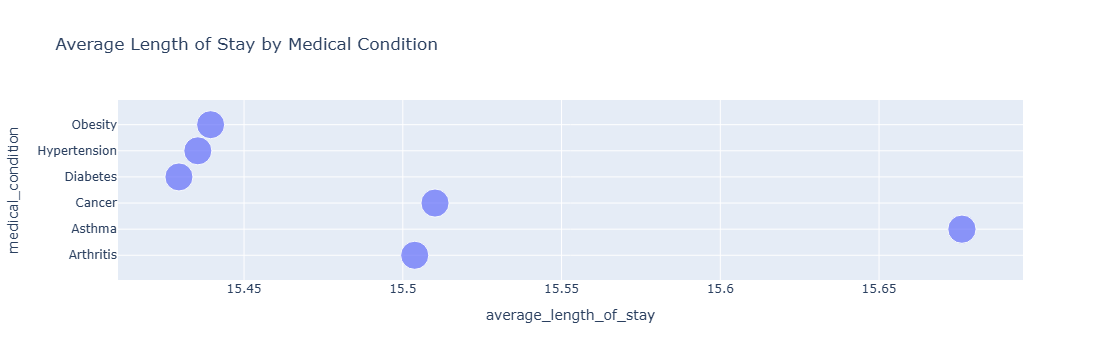

In [68]:
avg_stay = (healthcare.groupby('medical_condition')['length_of_stay'].mean().reset_index(name='average_length_of_stay'))
fig = px.scatter(
    avg_stay,
    x='average_length_of_stay',
    y='medical_condition',
    size='average_length_of_stay',
    title='Average Length of Stay by Medical Condition'
)

fig.show()

<p style="font-family:'Trebuchet MS', sans-serif; font-size: 20px; text-align: left; color: #1F77B4;">FINANCIAL ANALYSIS</p>

In [69]:
total_revenue = healthcare['billing_amount'].sum()
print(f"A total revenue of ${round(total_revenue)} was generated over the five-year period.")

A total revenue of $1404121601 was generated over the five-year period.


In [70]:
revenue_by_condition = (healthcare.groupby('medical_condition')['billing_amount'].sum().reset_index(name='total_revenue'))
fig = px.bar(
    revenue_by_condition.sort_values('total_revenue', ascending=True),
    x='total_revenue',
    y='medical_condition',
    orientation='h',
    title='Total Revenue by Medical Condition'
)

fig.update_layout(
    xaxis_title='Total Billing Amount',
    yaxis_title='Medical Condition'
)

fig.show()

In [71]:
revenue_by_insurance = (healthcare.groupby('insurance_provider')['billing_amount'].sum().reset_index(name='total_revenue'))
fig = px.bar(
    revenue_by_insurance.sort_values('total_revenue', ascending=True),
    x='total_revenue',
    y='insurance_provider',
    orientation='h',
    title='Total Revenue by Insurance Provider'
)

fig.update_layout(
    xaxis_title='Total Billing Amount',
    yaxis_title='Insurance Provider'
)

fig.show()

In [72]:
avg_billing = (healthcare.groupby('medical_condition')['billing_amount'].mean().reset_index(name='avg_billing_amount'))
fig = px.bar(
    avg_billing.sort_values('avg_billing_amount', ascending=True),
    x='medical_condition',
    y='avg_billing_amount',
    title='Average Billing Amount per Medical Condition'
)

fig.update_layout(
    xaxis_title='Average Billing Amount',
    yaxis_title='Medical Condition'
)

fig.show()

<p style="font-family:'Trebuchet MS', sans-serif; font-size: 20px; text-align: left; color: #1F77B4;">OPERATION EFFICIENCY</p>

In [73]:
visit_counts = healthcare['name'].value_counts()

In [74]:
readmitted_names = visit_counts[visit_counts > 1].index

In [75]:
readmitted_data = healthcare[healthcare['name'].isin(readmitted_names)]

In [76]:
condition_check = (
    readmitted_data
    .groupby('name')['medical_condition']
    .nunique()
    .reset_index(name='unique_conditions')
)

In [77]:
same_condition = (condition_check['unique_conditions'] == 1).sum()

In [78]:
same_condition

np.int64(4126)

In [79]:
different_conditions = (condition_check['unique_conditions'] > 1).sum()

In [80]:
different_conditions

np.int64(5245)

In [81]:
# Visualize readmission for the same medical condition
# Step 1: patients with only one condition
same_condition_patients = condition_check[
    condition_check['unique_conditions'] == 1
]['name']

# Step 2: filter original readmitted data
same_condition_data = readmitted_data[
    readmitted_data['name'].isin(same_condition_patients)
]
# Step 3: get ONE condition per patient (since it's the same for all their visits)
same_condition_unique = (
    same_condition_data
    .drop_duplicates(subset=['name'])   # ensures one row per patient
)

# Step 4: count by condition
condition_distribution = same_condition_unique['medical_condition'].value_counts()


In [82]:
fig = px.pie(
    values=condition_distribution.values,
    names=condition_distribution.index,
    title="Same-Condition Readmitted Patients by Medical Condition"
)

fig.show()

In [83]:
readmitted_data['name'].unique()

array(['adrienne bell', 'emily johnson', 'edward edwards', ...,
       'yvonne rice', 'gary sweeney', 'katherine webster'],
      shape=(9371,), dtype=object)

In [84]:
visit_counts = healthcare['name'].value_counts()

In [85]:
repeated_visits = (visit_counts - 1).clip(lower=0)

In [86]:
total_repeated_visits = repeated_visits.sum()

In [87]:
total_repeated_visits

np.int64(14693)

In [88]:
readmitted_data = readmitted_data.sort_values(['name', 'date_of_admission'])

In [90]:
repeated_visits_only = (
    readmitted_data
    .groupby('name')
    .apply(lambda x: x.iloc[1:])
    .reset_index(drop=True)
)

C:\Users\Oluwanifemi\AppData\Local\Temp\ipykernel_10524\2819896453.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [91]:
condition_distribution_repeats = repeated_visits_only['medical_condition'].value_counts()

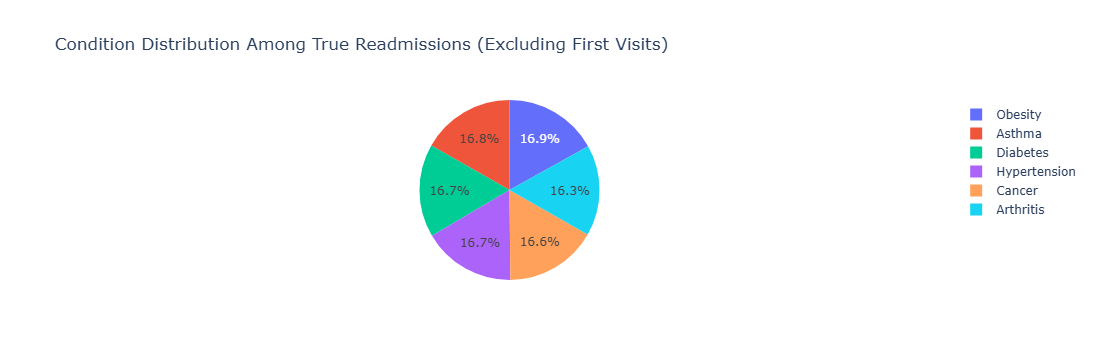

In [92]:
fig = px.pie(
    values=condition_distribution_repeats.values,
    names=condition_distribution_repeats.index,
    title="Condition Distribution Among True Readmissions (Excluding First Visits)"
)

fig.show()

<p style="font-family:'Trebuchet MS', sans-serif; font-size: 20px; text-align: left; color: #1F77B4;">DATA REPORT</p>